## Attention and Transformer Foundations

Goal:
- understand attention from first principles
- learn sequence tensor shapes
- implement self-attention
- implement multi-head attention
- visualize attention weights

In [1]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cpu
CUDA available: False
Using device: cpu


Sequence data in PyTorch

For transformers, a common tensor shape is:

(batch_size, sequence_length, embedding_dim)

This is often written as:

(B, T, D)

In [2]:
x = torch.randn(2,5,4)
print("shape:", x.shape)
print("batch size:", x.shape[0])
print("sequence length:", x.shape[1])
print("embedding dim:", x.shape[2])

shape: torch.Size([2, 5, 4])
batch size: 2
sequence length: 5
embedding dim: 4


What embeddings are:

An embedding is a vector representation of a token.


In [3]:
embedding = nn.Embedding(num_embeddings=10, embedding_dim=4)

token_ids = torch.tensor([[1, 3, 5, 7],
                          [2, 4, 6, 8]])

embedded = embedding(token_ids)

print("token ids shape:", token_ids.shape)
print("embedded shape:", embedded.shape)
print(embedded)

token ids shape: torch.Size([2, 4])
embedded shape: torch.Size([2, 4, 4])
tensor([[[ 1.7123, -0.5488, -1.2708, -1.1452],
         [ 0.3085, -0.4141,  1.3203,  0.9765],
         [-0.4153, -1.4954,  1.1354, -1.4783],
         [ 1.7258, -1.6659, -0.4010,  2.5627]],

        [[-0.5165,  0.8631, -1.1219,  0.9124],
         [-1.2003,  1.4660,  0.1646,  0.9261],
         [-0.1152, -0.9050, -1.2597, -0.4704],
         [-0.3488, -0.2728, -0.9251,  0.2729]]], grad_fn=<EmbeddingBackward0>)


Why attention exists

In sequence models, each position may need information from other positions.

Attention lets one token look at other tokens
and decide which ones matter more.

Attention intuition

For each position:
- Query = what am I looking for?
- Key = what do I contain?
- Value = what information should I send?

Attention compares queries with keys,
then uses the result to mix values.

In [5]:
Q = torch.tensor([[1.0, 0.0],
                  [0.0, 1.0]])

K = torch.tensor([[1.0, 0.0],
                  [0.0, 1.0]])

V = torch.tensor([[10.0, 1.0],
                  [1.0, 10.0]])

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: torch.Size([2, 2])
K shape: torch.Size([2, 2])
V shape: torch.Size([2, 2])


Compute attention scores

Scores are:
Q @ K^T


In [6]:
scores = Q @ K.T
print(scores)

tensor([[1., 0.],
        [0., 1.]])


Turn scores into probabilities with softmax

In [7]:
weights = torch.softmax(scores, dim=-1)
print(weights)

tensor([[0.7311, 0.2689],
        [0.2689, 0.7311]])


Use weights to combine values

In [8]:
output = weights @ V
print(output)

tensor([[7.5795, 3.4205],
        [3.4205, 7.5795]])


Full attention formula

Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) V

The scaling helps keep values stable when dimensions grow.

In [9]:
dk = Q.shape[-1]
scaled_scores = (Q @ K.T) / math.sqrt(dk)
scaled_weights = torch.softmax(scaled_scores, dim=-1)
scaled_output = scaled_weights @ V

print("scaled scores:")
print(scaled_scores)

print("\nscaled weights:")
print(scaled_weights)

print("\nscaled output:")
print(scaled_output)

scaled scores:
tensor([[0.7071, 0.0000],
        [0.0000, 0.7071]])

scaled weights:
tensor([[0.6698, 0.3302],
        [0.3302, 0.6698]])

scaled output:
tensor([[7.0279, 3.9721],
        [3.9721, 7.0279]])


Visualize attention weights

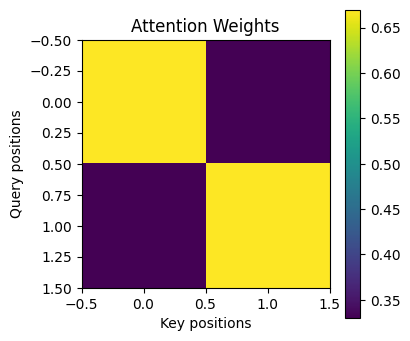

In [10]:
plt.figure(figsize=(4, 4))
plt.imshow(scaled_weights.numpy(), cmap="viridis")
plt.colorbar()
plt.title("Attention Weights")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.show()

Self-attention

In self-attention, Q, K, and V all come from the same input sequence.

In [11]:
x = torch.randn(1, 4, 6)
print(x.shape)

torch.Size([1, 4, 6])


Create linear projections for Q, K, V

In [12]:
d_model = 6

Wq = nn.Linear(d_model, d_model)
Wk = nn.Linear(d_model, d_model)
Wv = nn.Linear(d_model, d_model)

Q = Wq(x)
K = Wk(x)
V = Wv(x)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: torch.Size([1, 4, 6])
K shape: torch.Size([1, 4, 6])
V shape: torch.Size([1, 4, 6])


Batched attention scores

For batched sequence tensors:
Q shape = (B, T, D)
K transpose shape = (B, D, T)

So scores shape becomes:
(B, T, T)

In [13]:
scores = Q @ K.transpose(-2, -1)
print(scores.shape)

torch.Size([1, 4, 4])


In [14]:
weights = torch.softmax(scores / math.sqrt(d_model), dim=-1)
print(weights.shape)

torch.Size([1, 4, 4])


In [15]:
output = weights @ V
print(output.shape)

torch.Size([1, 4, 6])


Visualize one attention matrix from the batch


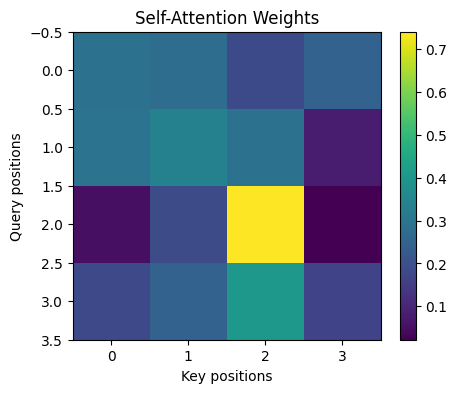

In [16]:
attention_matrix = weights[0].detach()

plt.figure(figsize=(5, 4))
plt.imshow(attention_matrix.numpy(), cmap="viridis")
plt.colorbar()
plt.title("Self-Attention Weights")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.show()

Wrap self-attention in a module

In [17]:
class SelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)

    def forward(self, x):
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        scores = Q @ K.transpose(-2, -1)
        weights = torch.softmax(scores / math.sqrt(x.shape[-1]), dim=-1)
        output = weights @ V

        return output, weights

In [18]:
attn = SelfAttention(d_model=8)

x = torch.randn(2, 5, 8)
out, weights = attn(x)

print("input shape:", x.shape)
print("output shape:", out.shape)
print("weights shape:", weights.shape)

input shape: torch.Size([2, 5, 8])
output shape: torch.Size([2, 5, 8])
weights shape: torch.Size([2, 5, 5])


Why output shape matches input shape

Attention mixes information across sequence positions,
but keeps:
- batch size
- sequence length
- embedding dimension


Multi-head attention idea

Instead of one attention operation,
use several heads in parallel.

Different heads can learn different relationships.

Multi-head attention shape idea

If:
d_model = 8
num_heads = 2

then each head gets:
head_dim = 4

In [19]:
d_model = 8
num_heads = 2
head_dim = d_model // num_heads

print("head_dim:", head_dim)

head_dim: 4


In [21]:
 # Split into heads manually
x = torch.randn(2, 5, 8)

B, T, D = x.shape
num_heads = 2
head_dim = D // num_heads

x_heads = x.view(B, T, num_heads, head_dim)
x_heads = x_heads.transpose(1, 2)

print("original shape:", x.shape)
print("heads shape:", x_heads.shape)

original shape: torch.Size([2, 5, 8])
heads shape: torch.Size([2, 2, 5, 4])


Meaning of new shape

(B, num_heads, T, head_dim)

Implement multi-head self-attention

In [22]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, D = x.shape

        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        scores = Q @ K.transpose(-2, -1)
        weights = torch.softmax(scores / math.sqrt(self.head_dim), dim=-1)

        out = weights @ V
        out = out.transpose(1, 2).contiguous().view(B, T, D)
        out = self.out_proj(out)

        return out, weights

In [23]:
mha = MultiHeadSelfAttention(d_model=8, num_heads=2)

x = torch.randn(2, 5, 8)
out, weights = mha(x)

print("input shape:", x.shape)
print("output shape:", out.shape)
print("weights shape:", weights.shape)

input shape: torch.Size([2, 5, 8])
output shape: torch.Size([2, 5, 8])
weights shape: torch.Size([2, 2, 5, 5])


Meaning of weight shape

weights shape:
(B, num_heads, T, T)

Each head gets its own attention matrix.

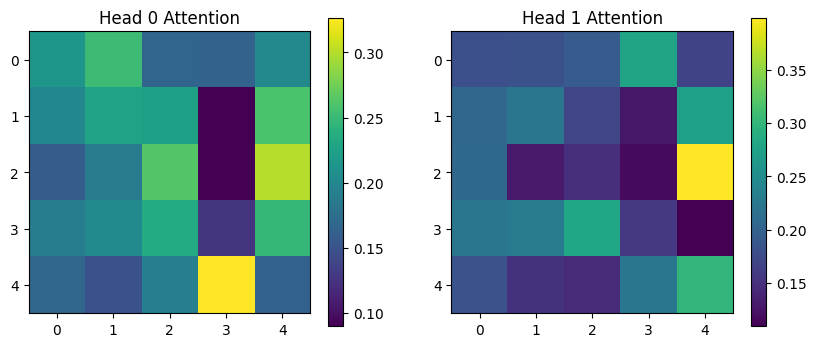

In [24]:
head0 = weights[0, 0].detach()
head1 = weights[0, 1].detach()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(head0.numpy(), cmap="viridis")
plt.colorbar()
plt.title("Head 0 Attention")

plt.subplot(1, 2, 2)
plt.imshow(head1.numpy(), cmap="viridis")
plt.colorbar()
plt.title("Head 1 Attention")

plt.show()

Causal masking

In autoregressive generation,
a token should not look at future tokens.

We use a mask for that.

In [25]:
T = 5
mask = torch.tril(torch.ones(T, T))
print(mask)

tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])


Apply mask to attention scores

Masked positions get a very negative number before softmax.


In [26]:
scores = torch.randn(5, 5)

masked_scores = scores.masked_fill(mask == 0, float("-inf"))
weights = torch.softmax(masked_scores, dim=-1)

print("scores:")
print(scores)

print("\nmasked weights:")
print(weights)

scores:
tensor([[-1.5966,  0.5463, -0.0179,  0.0302,  0.3193],
        [-0.4241, -1.4222, -0.1351, -1.3900, -0.9919],
        [ 0.2348,  0.6968,  0.0920,  1.4455, -1.0058],
        [-0.1374,  2.1833, -0.1979,  1.0253,  0.7652],
        [-0.4893,  0.6323, -0.3475,  0.8004, -0.0456]])

masked weights:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7307, 0.2693, 0.0000, 0.0000, 0.0000],
        [0.2895, 0.4595, 0.2510, 0.0000, 0.0000],
        [0.0653, 0.6646, 0.0614, 0.2087, 0.0000],
        [0.0960, 0.2948, 0.1107, 0.3488, 0.1497]])


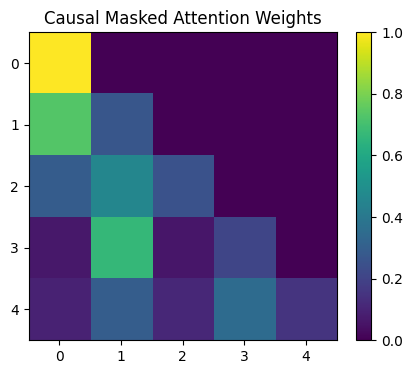

In [27]:
plt.figure(figsize=(5, 4))
plt.imshow(weights.numpy(), cmap="viridis")
plt.colorbar()
plt.title("Causal Masked Attention Weights")
plt.show()

## Multi-head attention with optional causal mask

In [28]:
class MaskedMultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x, causal=False):
        B, T, D = x.shape

        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        scores = Q @ K.transpose(-2, -1)
        scores = scores / math.sqrt(self.head_dim)

        if causal:
            mask = torch.tril(torch.ones(T, T, device=x.device))
            scores = scores.masked_fill(mask == 0, float("-inf"))

        weights = torch.softmax(scores, dim=-1)

        out = weights @ V
        out = out.transpose(1, 2).contiguous().view(B, T, D)
        out = self.out_proj(out)

        return out, weights

In [29]:
masked_mha = MaskedMultiHeadSelfAttention(d_model=8, num_heads=2)

x = torch.randn(1, 5, 8)
out, weights = masked_mha(x, causal=True)

print("output shape:", out.shape)
print("weights shape:", weights.shape)

output shape: torch.Size([1, 5, 8])
weights shape: torch.Size([1, 2, 5, 5])


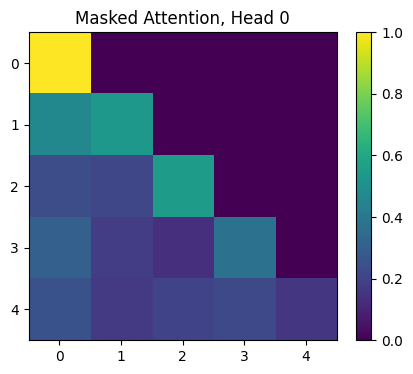

In [30]:
plt.figure(figsize=(5, 4))
plt.imshow(weights[0, 0].detach().numpy(), cmap="viridis")
plt.colorbar()
plt.title("Masked Attention, Head 0")
plt.show()

## Positional information

Attention alone does not know token order.
So transformers add positional information.

In [32]:
class TokenAndPositionEmbedding(nn.Module):
    def __init__(self, vocab_size, max_len, d_model):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_len, d_model)

    def forward(self, token_ids):
        B, T = token_ids.shape
        positions = torch.arange(T, device=token_ids.device).unsqueeze(0).expand(B, T)

        token_vectors = self.token_embed(token_ids)
        pos_vectors = self.pos_embed(positions)

        return token_vectors + pos_vectors


In [33]:
embed_layer = TokenAndPositionEmbedding(vocab_size=20, max_len=10, d_model=8)

token_ids = torch.tensor([[1, 2, 3, 4, 5]])
embedded = embed_layer(token_ids)

print("token ids shape:", token_ids.shape)
print("embedded shape:", embedded.shape)

token ids shape: torch.Size([1, 5])
embedded shape: torch.Size([1, 5, 8])


Transformer block idea

A simplified transformer block usually has:
- multi-head attention
- residual connection
- layer normalization
- feed-forward network
- another residual connection
- another layer normalization

In [34]:
class FeedForward(nn.Module):
    def __init__(self, d_model, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, d_model)
        )

    def forward(self, x):
        return self.net(x)

In [36]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, hidden_dim):
        super().__init__()
        self.attn = MaskedMultiHeadSelfAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, hidden_dim)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, causal=False):
        attn_out, weights = self.attn(x, causal=causal)
        x = self.norm1(x + attn_out)

        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)

        return x, weights


In [37]:
block = TransformerBlock(d_model=8, num_heads=2, hidden_dim=16)

x = torch.randn(2, 5, 8)
out, weights = block(x, causal=True)

print("input shape:", x.shape)
print("output shape:", out.shape)
print("weights shape:", weights.shape)

input shape: torch.Size([2, 5, 8])
output shape: torch.Size([2, 5, 8])
weights shape: torch.Size([2, 2, 5, 5])


## Build a tiny transformer model

In [38]:
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, max_len, d_model, num_heads, hidden_dim):
        super().__init__()
        self.embed = TokenAndPositionEmbedding(vocab_size, max_len, d_model)
        self.block = TransformerBlock(d_model, num_heads, hidden_dim)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, token_ids, causal=False):
        x = self.embed(token_ids)
        x, weights = self.block(x, causal=causal)
        logits = self.lm_head(x)
        return logits, weights

In [39]:
model = TinyTransformer(
    vocab_size=30,
    max_len=10,
    d_model=8,
    num_heads=2,
    hidden_dim=16
)

token_ids = torch.tensor([[1, 5, 7, 2, 9],
                          [3, 4, 8, 1, 0]])

logits, weights = model(token_ids, causal=True)

print("token ids shape:", token_ids.shape)
print("logits shape:", logits.shape)
print("weights shape:", weights.shape)

token ids shape: torch.Size([2, 5])
logits shape: torch.Size([2, 5, 30])
weights shape: torch.Size([2, 2, 5, 5])


Interpret logits shape

If logits shape is:
(B, T, vocab_size)

then for each token position,
the model predicts scores over vocabulary items.

In [40]:
print(logits[0, 0])
print("shape:", logits[0, 0].shape)

tensor([ 0.7354,  0.3619, -0.5960, -0.8506, -0.9936, -0.2325,  0.3049,  0.2255,
        -0.4520, -0.3834, -0.0682,  1.1383, -0.2913,  0.2248,  0.3397, -1.8510,
        -0.6660,  0.0947, -0.6242, -0.3073,  0.2141, -0.3797,  0.4953, -0.7070,
         0.6730,  0.7245, -0.5030, -0.4430,  0.3553, -0.6233],
       grad_fn=<SelectBackward0>)
shape: torch.Size([30])


Predicted token ids

In [41]:
pred_tokens = torch.argmax(logits, dim=-1)
print(pred_tokens)

tensor([[11, 28,  0, 13, 15],
        [ 9, 13,  8, 13, 15]])


Visualize one head from the transformer block

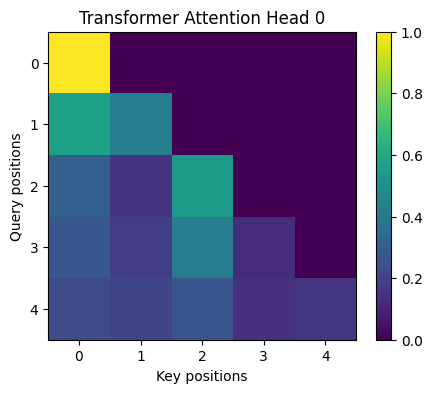

In [42]:
plt.figure(figsize=(5, 4))
plt.imshow(weights[0, 0].detach().numpy(), cmap="viridis")
plt.colorbar()
plt.title("Transformer Attention Head 0")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.show()

Compare masked vs unmasked attention

In [43]:
x = torch.randn(1, 5, 8)

block = TransformerBlock(d_model=8, num_heads=2, hidden_dim=16)

out_unmasked, weights_unmasked = block(x, causal=False)
out_masked, weights_masked = block(x, causal=True)

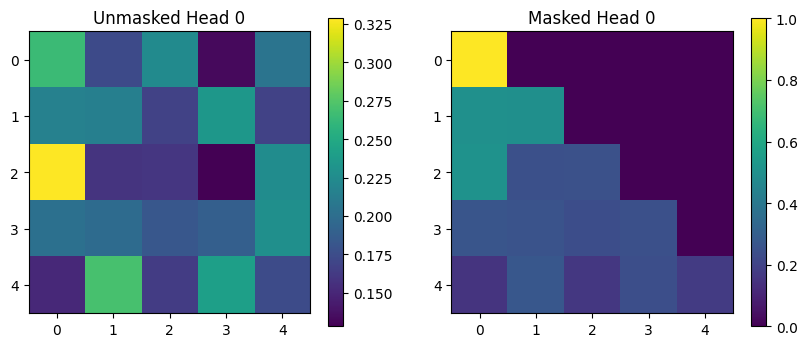

In [44]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(weights_unmasked[0, 0].detach().numpy(), cmap="viridis")
plt.colorbar()
plt.title("Unmasked Head 0")

plt.subplot(1, 2, 2)
plt.imshow(weights_masked[0, 0].detach().numpy(), cmap="viridis")
plt.colorbar()
plt.title("Masked Head 0")

plt.show()

3D visualization of attention weights

In [45]:
from mpl_toolkits.mplot3d import Axes3D

In [46]:
attn_matrix = weights_masked[0, 0].detach().numpy()
T = attn_matrix.shape[0]

x_coords = []
y_coords = []
z_coords = []

for i in range(T):
    for j in range(T):
        x_coords.append(i)
        y_coords.append(j)
        z_coords.append(attn_matrix[i, j])

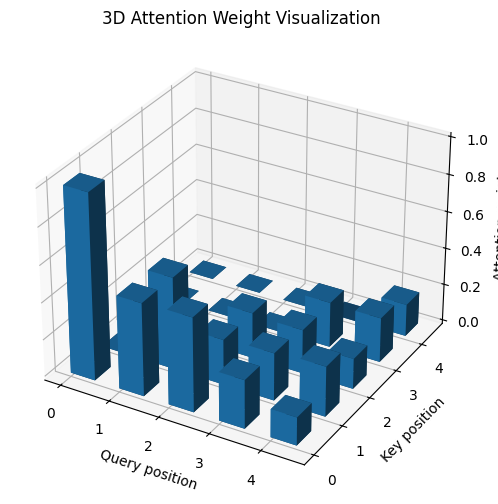

In [47]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.bar3d(
    x_coords,
    y_coords,
    [0] * len(z_coords),
    0.5,
    0.5,
    z_coords
)

ax.set_xlabel("Query position")
ax.set_ylabel("Key position")
ax.set_zlabel("Attention weight")
ax.set_title("3D Attention Weight Visualization")
plt.show()

Production habit: inspect tensor shapes carefully
Transformers are shape-sensitive.

In [48]:
def print_transformer_shapes(token_ids, vocab_size=30, max_len=10, d_model=8, num_heads=2, hidden_dim=16):
    model = TinyTransformer(vocab_size, max_len, d_model, num_heads, hidden_dim)

    x = model.embed(token_ids)
    print("after embedding:", x.shape)

    x, weights = model.block(x, causal=True)
    print("after transformer block:", x.shape)
    print("attention weights:", weights.shape)

    logits = model.lm_head(x)
    print("after lm head:", logits.shape)

In [49]:
token_ids = torch.tensor([[1, 2, 3, 4, 5]])
print_transformer_shapes(token_ids)

after embedding: torch.Size([1, 5, 8])
after transformer block: torch.Size([1, 5, 8])
attention weights: torch.Size([1, 2, 5, 5])
after lm head: torch.Size([1, 5, 30])


Count parameters
Production habit:
know model size.

In [50]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("total params:", total_params)
print("trainable params:", trainable_params)

total params: 1190
trainable params: 1190


Save weights

In [51]:
torch.save(model.state_dict(), "tiny_transformer.pth")
print("model saved")

model saved
